In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from datasets import load_dataset
from wordcloud import WordCloud
from collections import Counter
import re
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.family': 'sans-serif',
    'axes.titlesize': 13,
    'axes.labelsize': 11
})
PALETTE = ['#E24B4A', '#EF9F27', '#639922']

# **Dataset de Sentimiento — amazon_reviews_multi (ES)**

In [8]:
print("--- CARGA DE DATASET DE SENTIMIENTOS (SetFit Amazon Reviews ES) ---")

# Instalar librería si no está instalada
!pip install datasets -q

from datasets import load_dataset
import pandas as pd

# Cargar dataset desde Hugging Face
dataset = load_dataset("SetFit/amazon_reviews_multi_es")

# Convertir split train a DataFrame
df_amazon = pd.DataFrame(dataset["train"])

# Ver columnas disponibles
print("Columnas:", df_amazon.columns.tolist())

# Renombrar para que sea más claro en tu proyecto
df_amazon = df_amazon.rename(columns={
    "text": "review_body",
    "label": "stars"
})

# Inspección básica
print(f"\nTotal de filas: {len(df_amazon)}")

print("\nValores nulos:")
print(df_amazon.isnull().sum())

print("\nDistribución de clases:")
print(df_amazon["stars"].value_counts().sort_index())

print("\nMuestra de datos:")
display(df_amazon.head())

--- CARGA DE DATASET DE SENTIMIENTOS (SetFit Amazon Reviews ES) ---


Repo card metadata block was not found. Setting CardData to empty.


Columnas: ['id', 'text', 'label', 'label_text']

Total de filas: 200000

Valores nulos:
id             0
review_body    0
stars          0
label_text     0
dtype: int64

Distribución de clases:
stars
0    40000
1    40000
2    40000
3    40000
4    40000
Name: count, dtype: int64

Muestra de datos:


,id,review_body,stars,label_text
0,es_0491108,Nada bueno se me fue ka pantalla en menos de 8...,0,0
1,es_0869872,"Horrible, nos tuvimos que comprar otro porque ...",0,0
2,es_0811721,Te obligan a comprar dos unidades y te llega s...,0,0
3,es_0359921,"No entro en descalificar al vendedor, solo pue...",0,0
4,es_0068940,Llega tarde y co la talla equivocada,0,0


**Distribución de estrellas**

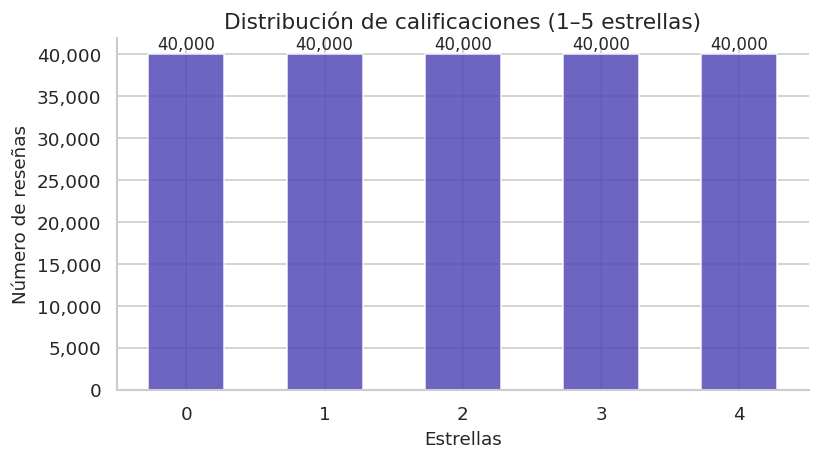

In [11]:
fig, ax = plt.subplots(figsize=(7, 4))
counts = df['stars'].value_counts().sort_index()
bars = ax.bar(counts.index.astype(str), counts.values, color='#534AB7', alpha=0.85, width=0.55)

for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
            f'{bar.get_height():,}', ha='center', va='bottom', fontsize=10)

ax.set_title('Distribución de calificaciones (1–5 estrellas)')
ax.set_xlabel('Estrellas')
ax.set_ylabel('Número de reseñas')
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.savefig('fig1_distribucion_estrellas.png', bbox_inches='tight')
plt.show()

Mapeo a clases de **sentimiento**

In [12]:
def map_sentiment(stars):
    if stars <= 2: return 'negativo'
    elif stars == 3: return 'neutro'
    else: return 'positivo'

df['sentimiento'] = df['stars'].apply(map_sentiment)
df['sentimiento'].value_counts()

,count
sentimiento,
negativo,120000
neutro,40000
positivo,40000


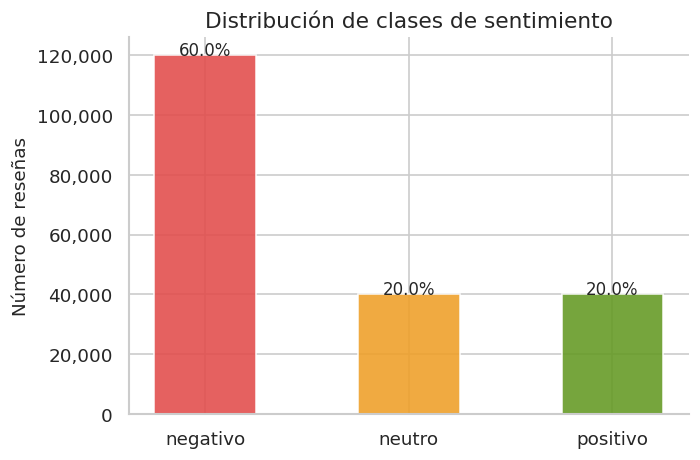

In [13]:
fig, ax = plt.subplots(figsize=(6, 4))
order = ['negativo', 'neutro', 'positivo']
counts_sent = df['sentimiento'].value_counts()[order]
bars = ax.bar(order, counts_sent.values, color=PALETTE, alpha=0.88, width=0.5)

for bar in bars:
    pct = bar.get_height() / len(df) * 100
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 150,
            f'{pct:.1f}%', ha='center', fontsize=10)

ax.set_title('Distribución de clases de sentimiento')
ax.set_ylabel('Número de reseñas')
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.savefig('fig2_distribucion_sentimiento.png', bbox_inches='tight')
plt.show()

**Longitud de texto por sentimiento**

In [14]:
df['n_palabras'] = df['review_body'].fillna('').apply(lambda x: len(x.split()))

print(df.groupby('sentimiento')['n_palabras'].describe()[['mean','50%','max']].round(1))

             mean   50%    max
sentimiento                   
negativo     29.5  23.0  506.0
neutro       25.9  21.0  394.0
positivo     24.5  20.0  551.0


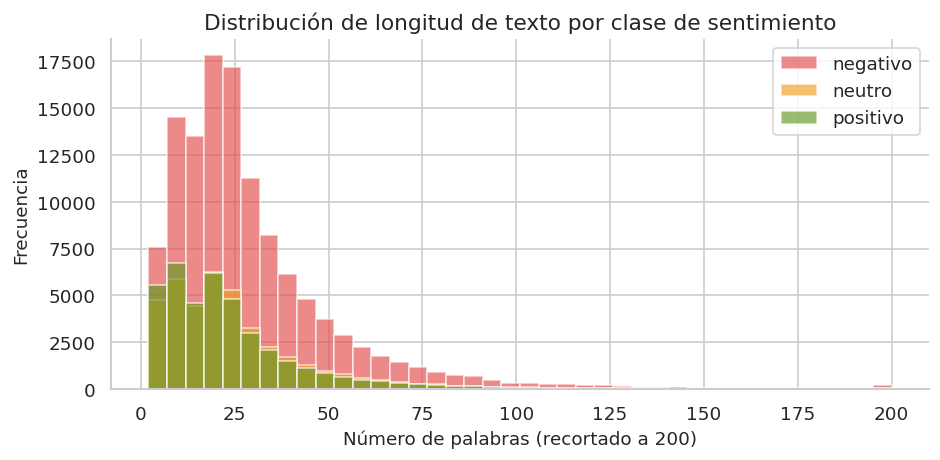

In [15]:
fig, ax = plt.subplots(figsize=(8, 4))

for i, (clase, color) in enumerate(zip(order, PALETTE)):
    datos = df[df['sentimiento'] == clase]['n_palabras'].clip(upper=200)
    ax.hist(datos, bins=40, alpha=0.65, label=clase, color=color)

ax.set_title('Distribución de longitud de texto por clase de sentimiento')
ax.set_xlabel('Número de palabras (recortado a 200)')
ax.set_ylabel('Frecuencia')
ax.legend()
plt.tight_layout()
plt.savefig('fig3_longitud_sentimiento.png', bbox_inches='tight')
plt.show()

# **Palabras más frecuentes por clase**

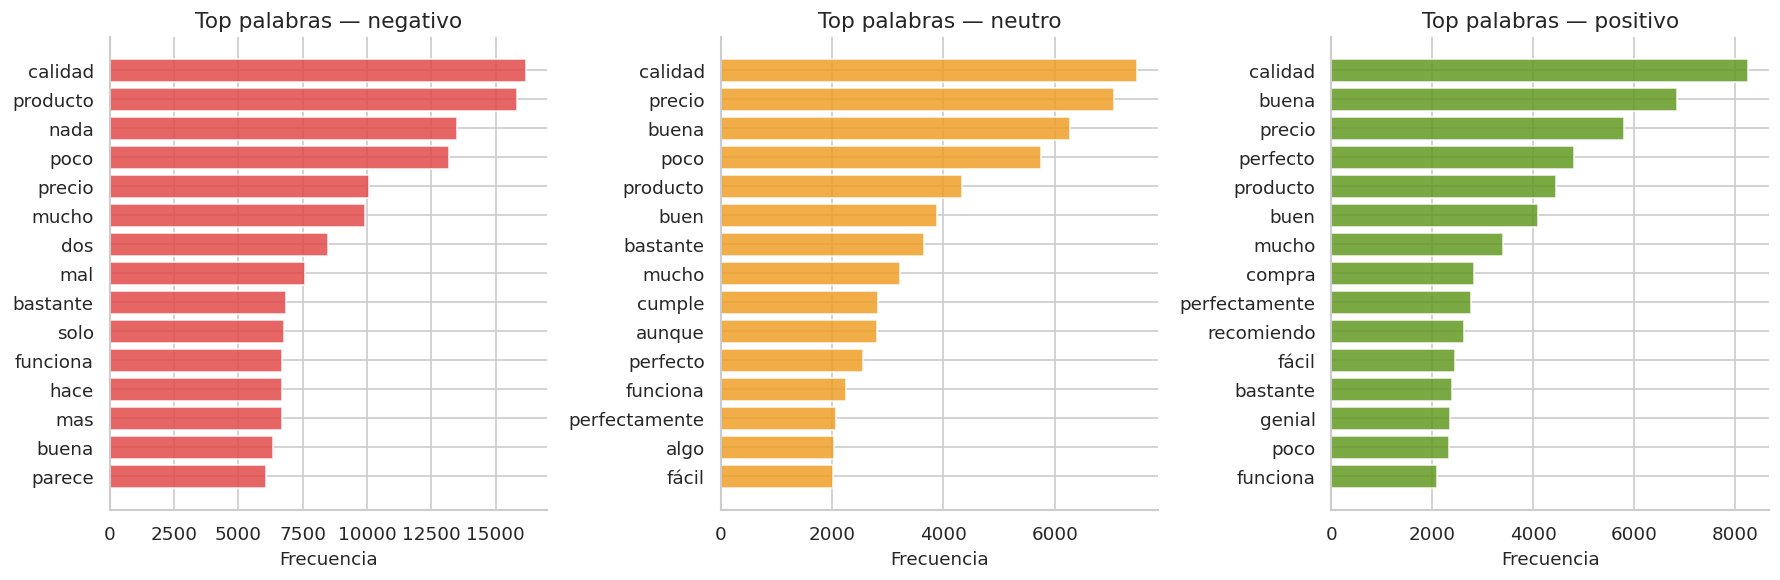

In [16]:
STOPWORDS_ES = {
    'de','la','el','en','y','a','que','los','se','del','las','un','por',
    'una','con','no','es','su','al','lo','más','pero','si','como','me',
    'le','mi','muy','este','esta','ya','también','hay','para','son','fue',
    'está','todo','bien','cuando','sobre','sin','han','he','o','e','ni',
    'era','ser','tiene','había','sus','hay','mismo','tan','qué','así',
    'unos','desde','porque','hasta','te','les','nos','yo','tu','tus'
}

def top_words(texts, n=15):
    tokens = []
    for t in texts:
        words = re.sub(r'[^a-záéíóúüñ ]', ' ', str(t).lower()).split()
        tokens.extend([w for w in words if w not in STOPWORDS_ES and len(w) > 2])
    return Counter(tokens).most_common(n)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, clase, color in zip(axes, order, PALETTE):
    subset = df[df['sentimiento'] == clase]['review_body']
    words, freqs = zip(*top_words(subset))
    ax.barh(list(reversed(words)), list(reversed(freqs)), color=color, alpha=0.85)
    ax.set_title(f'Top palabras — {clase}')
    ax.set_xlabel('Frecuencia')

plt.tight_layout()
plt.savefig('fig4_top_palabras_sentimiento.png', bbox_inches='tight')
plt.show()

**WordClouds por sentimiento**

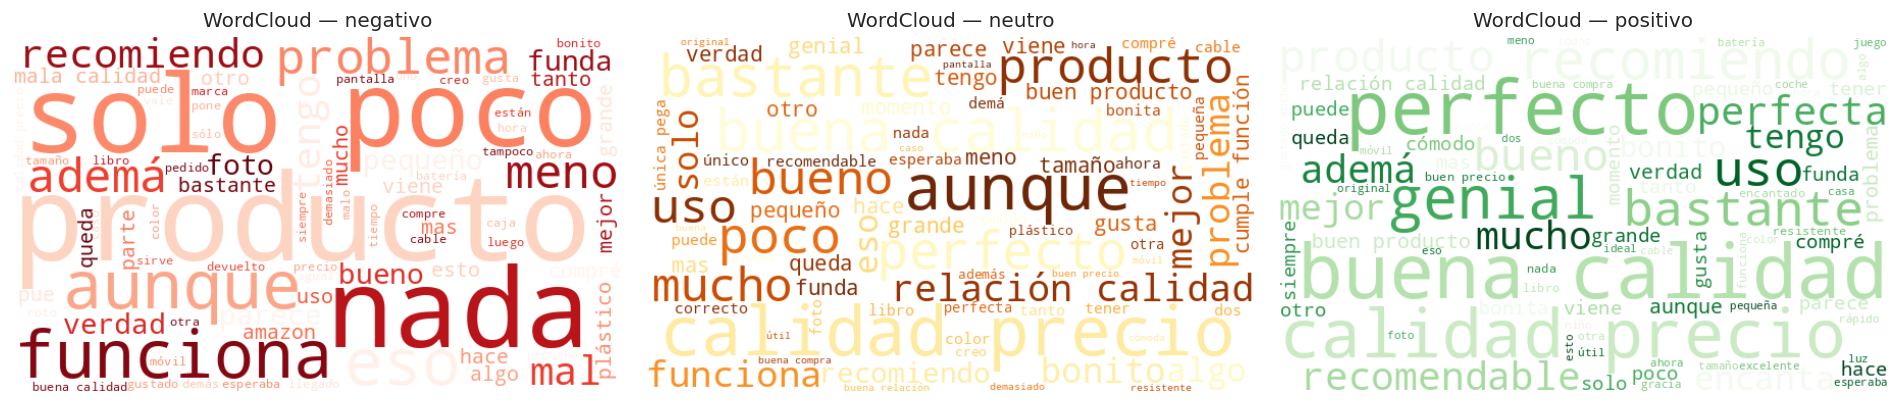

In [17]:
COLORMAPS = {'negativo': 'Reds', 'neutro': 'YlOrBr', 'positivo': 'Greens'}

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, clase in zip(axes, order):
    texto = ' '.join(df[df['sentimiento'] == clase]['review_body'].fillna(''))
    texto_limpio = re.sub(r'[^a-záéíóúüñ ]', ' ', texto.lower())
    texto_limpio = ' '.join([w for w in texto_limpio.split() if w not in STOPWORDS_ES and len(w) > 2])

    wc = WordCloud(
        width=600, height=350, background_color='white',
        max_words=80, colormap=COLORMAPS[clase]
    ).generate(texto_limpio)

    ax.imshow(wc, interpolation='bilinear')
    ax.set_title(f'WordCloud — {clase}', fontsize=12)
    ax.axis('off')

plt.tight_layout()
plt.savefig('fig5_wordcloud_sentimiento.png', bbox_inches='tight')
plt.show()

# **Dataset de Intenciones — Fonazo**

In [18]:
df_int = pd.read_csv('fonazo_intenciones_dataset.csv')

print(df_int.shape)
df_int.head(5)

(96, 2)


,texto,intencion
0,¿Tienen el iPhone 15 Pro en 256GB?,consulta_producto
1,¿Tienen stock del 16 Pro Max?,consulta_producto
2,¿Le hace al iPhone 13 el case MagSafe?,consulta_producto
3,¿En qué colores tienen el iPhone 16?,consulta_producto
4,Hola ¿tienen el 11 reacondicionado?,consulta_producto


In [19]:
df_int.info()
print('\nNulos:', df_int.isnull().sum().sum())
print('Clases:', df_int['intencion'].nunique())
df_int['intencion'].value_counts()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96 entries, 0 to 95
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   texto      96 non-null     object
 1   intencion  96 non-null     object
dtypes: object(2)
memory usage: 1.6+ KB

Nulos: 0
Clases: 8


,count
intencion,
consulta_producto,12
consulta_precio,12
consulta_servicio_tecnico,12
seguimiento_reparacion,12
queja_producto_servicio,12
solicitud_garantia_cambio,12
saludo_cierre,12
escalamiento_urgente,12


**Distribución de clases**

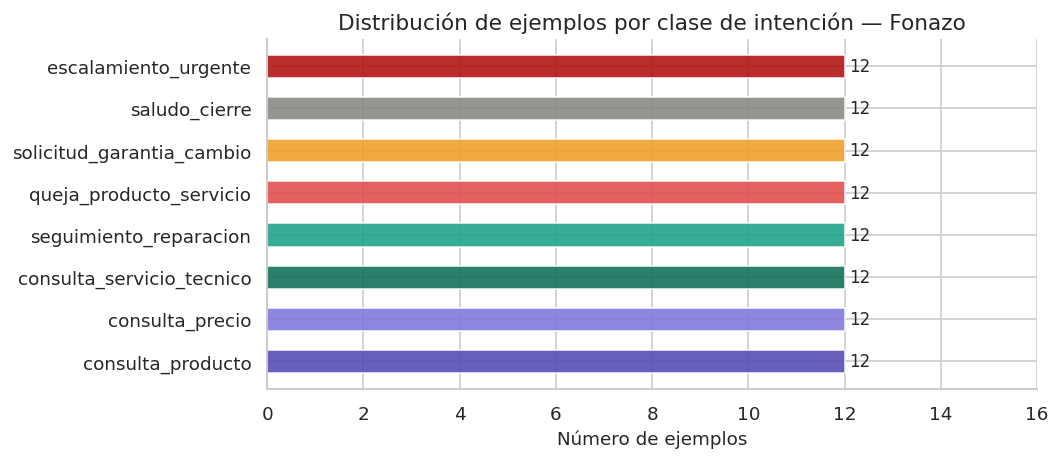

In [20]:
CLASS_COLORS = {
    'consulta_producto':       '#534AB7',
    'consulta_precio':         '#7F77DD',
    'consulta_servicio_tecnico':'#0F6E56',
    'seguimiento_reparacion':  '#1DA186',
    'queja_producto_servicio': '#E24B4A',
    'solicitud_garantia_cambio':'#EF9F27',
    'saludo_cierre':           '#888780',
    'escalamiento_urgente':    '#B01010'
}

conteo = df_int['intencion'].value_counts()
colores = [CLASS_COLORS[c] for c in conteo.index]

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.barh(conteo.index, conteo.values, color=colores, alpha=0.88, height=0.55)

for bar in bars:
    ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
            str(int(bar.get_width())), va='center', fontsize=10)

ax.set_title('Distribución de ejemplos por clase de intención — Fonazo')
ax.set_xlabel('Número de ejemplos')
ax.set_xlim(0, 16)
plt.tight_layout()
plt.savefig('fig6_distribucion_intenciones.png', bbox_inches='tight')
plt.show()

**Longitud promedio de mensaje por clase**

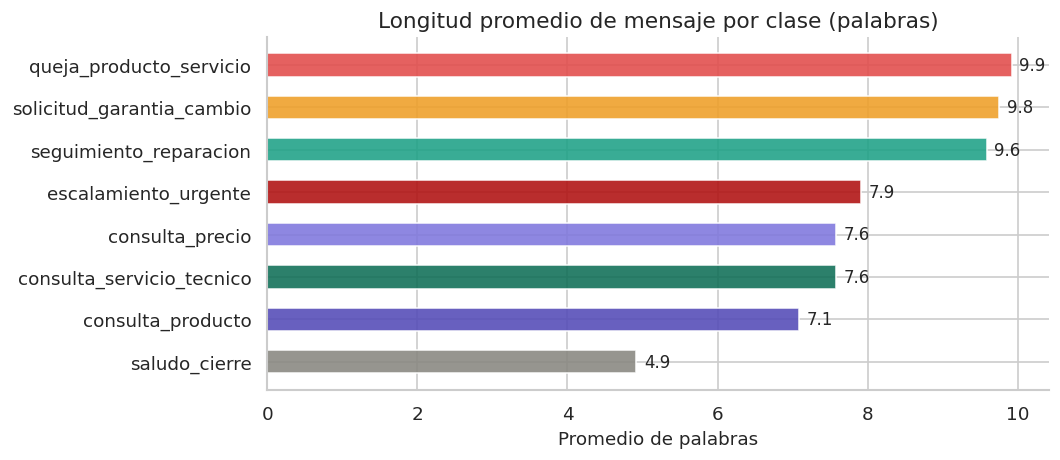

In [21]:
df_int['n_palabras'] = df_int['texto'].apply(lambda x: len(str(x).split()))
df_int['n_chars']    = df_int['texto'].apply(len)

avg_len = df_int.groupby('intencion')['n_palabras'].mean().sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 4))
colores_sorted = [CLASS_COLORS[c] for c in avg_len.index]
bars = ax.barh(avg_len.index, avg_len.values, color=colores_sorted, alpha=0.88, height=0.55)

for bar in bars:
    ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
            f'{bar.get_width():.1f}', va='center', fontsize=10)

ax.set_title('Longitud promedio de mensaje por clase (palabras)')
ax.set_xlabel('Promedio de palabras')
plt.tight_layout()
plt.savefig('fig7_longitud_intenciones.png', bbox_inches='tight')
plt.show()

**Tokens más frecuentes por clase de intención**

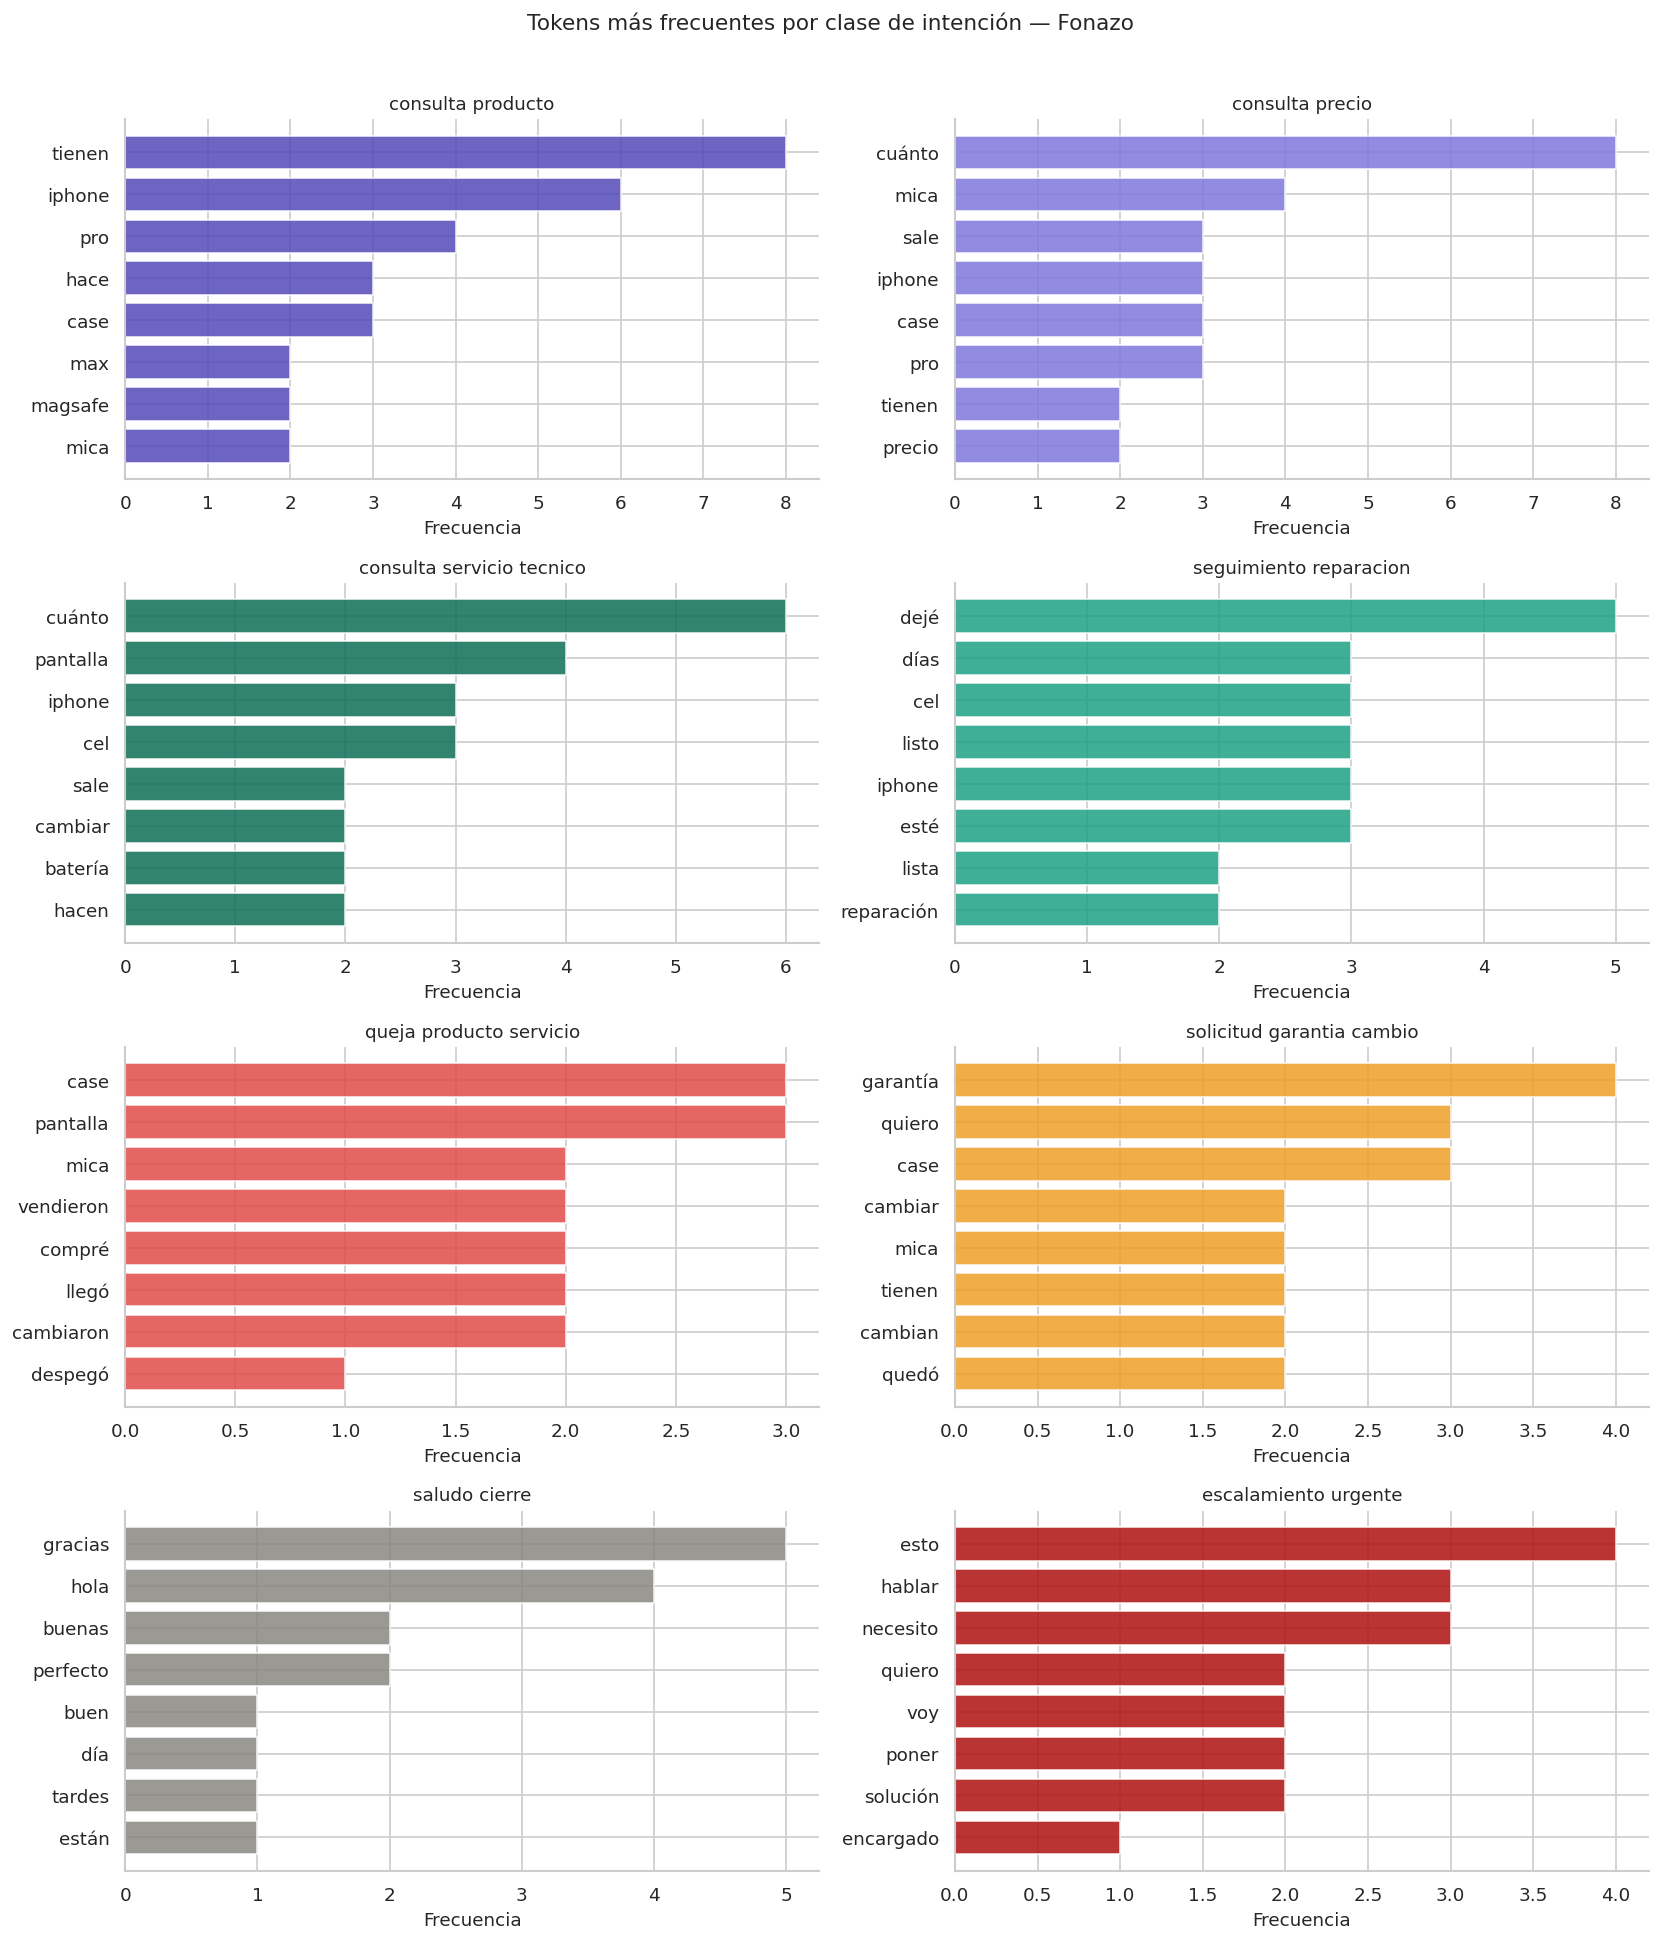

In [22]:
clases = df_int['intencion'].unique()
fig, axes = plt.subplots(4, 2, figsize=(14, 16))
axes = axes.flatten()

for ax, clase in zip(axes, clases):
    subset = df_int[df_int['intencion'] == clase]['texto']
    resultado = top_words(subset, n=8)
    if not resultado:
        continue
    words, freqs = zip(*resultado)
    color = CLASS_COLORS.get(clase, '#534AB7')
    ax.barh(list(reversed(words)), list(reversed(freqs)), color=color, alpha=0.85)
    ax.set_title(clase.replace('_', ' '), fontsize=11)
    ax.set_xlabel('Frecuencia')

plt.suptitle('Tokens más frecuentes por clase de intención — Fonazo', y=1.01, fontsize=13)
plt.tight_layout()
plt.savefig('fig8_tokens_intenciones.png', bbox_inches='tight')
plt.show()

**Vocabulario total del corpus de intenciones**

In [23]:
todos_tokens = []
for texto in df_int['texto']:
    palabras = re.sub(r'[^a-záéíóúüñ ]', ' ', str(texto).lower()).split()
    todos_tokens.extend(palabras)

vocab = set(todos_tokens)
print(f'Total de tokens (con repetición): {len(todos_tokens)}')
print(f'Vocabulario único:                {len(vocab)}')
print(f'Tokens específicos del dominio:   mica, quiñada, rajada, cel, magsafe, iphone')

terminos_dominio = ['mica', 'quiñada', 'rajada', 'cel', 'magsafe', 'iphone', 'hace', 'sale', 'listo']
print('\nPresencia en vocabulario:')
for t in terminos_dominio:
    print(f'  {t:20s} → {"✓" if t in vocab else "✗"}')

Total de tokens (con repetición): 743
Vocabulario único:                255
Tokens específicos del dominio:   mica, quiñada, rajada, cel, magsafe, iphone

Presencia en vocabulario:
  mica                 → ✓
  quiñada              → ✓
  rajada               → ✓
  cel                  → ✓
  magsafe              → ✓
  iphone               → ✓
  hace                 → ✓
  sale                 → ✓
  listo                → ✓
